# 400 YouDo 2 — Solution

Bu problemde bir **Matrix Factorization (Matris Çarpanlarına Ayırma)** tabanlı öneri sistemi kuruyoruz.
Amacımız elimizdeki kısıtlı ve seyrek puanlama (rating) verisini kullanarak her kullanıcı ($u$) ve her film ($v$) için gizli (latent) özellik vektörleri öğrenmek.

Öğrenilen bu vektörlerin çarpımı ($u \times v$) bize orijinal matrisi ($r$) yaklaşık olarak geri verecek ve eksik puanları tahmin etmemizi sağlayacaktır.

## Veri Yükleme ve Matris Tanımı

Kullanıcı sayısı $20$, Film sayısı $1000$'dir.
Verideki her puan $r_{ij}$ için, kullanıcının vektörü $u_i \in \mathbb{R}^{1 \times 4}$ ve filmin vektörü $v_j \in \mathbb{R}^{4 \times 1}$ olmak üzere:
$$ r_{ij} \approx u_i \cdot v_j $$

In [19]:
# Jupyter ortamında kütüphane sorununu kökten çözmek için magic command
%pip install -q matplotlib pandas numpy

You should consider upgrading via the '/Users/yusufalimertyurek/Desktop/capstone/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Eğer dosya yoksa örnek bir veri oluşturalım, varsa onu kullanalım.
import os
if os.path.exists('ratings_long.csv'):
    df = pd.read_csv('ratings_long.csv')
else:
    # Rastgele bir ratings verisi üretimi (örnek için)
    np.random.seed(42)
    users = np.random.randint(0, 20, 500)
    movies = np.random.randint(0, 1000, 500)
    ratings = np.random.randint(1, 6, 500)
    df = pd.DataFrame({'userId': users, 'movieId': movies, 'rating': ratings}).drop_duplicates(subset=['userId', 'movieId'])

print(f"Toplam Puanlama Sayısı: {len(df)}")
df.head()

Toplam Puanlama Sayısı: 496


,userId,movieId,rating
0,6,750,3
1,19,587,1
2,14,8,2
3,10,73,3
4,7,953,2


## Problem ve Loss (Kayıp) Fonksiyonu

Bu problemdeki amacımız, aşağıdaki **L2 Regülarizasyonlu Convex Kayıp Fonksiyonu (MSE)**'nu en aza indiren $u$ ve $v$ matrislerini bulmaktır:

$$ L(u, v) = \sum_{i,j \in \Omega} (r_{ij} - u_i \cdot v_j)^2 + \lambda \left( \sum_i \|u_i\|_2^2 + \sum_j \|v_j\|_2^2 \right) $$

Burada:
- $\Omega$: Elimizdeki bilinen (kullanıcı, film, puan) üçlüleri
- $\lambda$: Modelin ezberlemesini (overfitting) engelleyen L2 (Ridge) ceza parametresidir.

Her bir gözlem (hata: $e_{ij} = r_{ij} - u_i \cdot v_j$) için Gradient (Türev) güncellemeleri şu şekildedir:
- $\frac{\partial L}{\partial u_i} = -2 e_{ij} v_j + 2 \lambda u_i$
- $\frac{\partial L}{\partial v_j} = -2 e_{ij} u_i + 2 \lambda v_j$

Aşağıda **Gradient Descent** kullanarak bu fonksiyonu optimize ediyorum.

In [21]:
# Başlangıç değişkenleri
R_vals = df.values # [userId, movieId, rating]
n_users = 20
n_movies = 1000
k = 4 # Latent feature boyutu

np.random.seed(42)
u = np.random.normal(scale=1./k, size=(n_users, k))
v = np.random.normal(scale=1./k, size=(k, n_movies))

# Hiperparametreler
epochs = 200
learning_rate = 0.5 # Hızlı yakınsama için ayarlanmış oran
lamb = 0.1 # L2 regularization

history = []

for epoch in range(epochs):
    loss = 0
    gu = np.zeros_like(u)
    gv = np.zeros_like(v)
    
    # Tüm bilinen puanlar üzerinden geçiyoruz (Stochastic olmayan Full Batch)
    for i in range(len(R_vals)):
        user = int(R_vals[i, 0])
        movie = int(R_vals[i, 1])
        r_ij = R_vals[i, 2]
        
        # Tahmin ve hata (e_ij)
        pred = np.dot(u[user, :], v[:, movie])
        e_ij = r_ij - pred
        loss += e_ij**2
        
        # Gradient hesaplama
        gu[user, :] += -2 * e_ij * v[:, movie]
        gv[:, movie] += -2 * e_ij * u[user, :]
        
    # Regülarizasyon (Kayıp ve Gradient'lere ekleme)
    loss += lamb * (np.sum(u**2) + np.sum(v**2))
    gu += 2 * lamb * u
    gv += 2 * lamb * v
    
    # Parametre güncelleme (Gradient Descent)
    u -= learning_rate * (gu / len(R_vals))
    v -= learning_rate * (gv / len(R_vals))
    
    history.append(loss)
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | Grad Norm u: {np.linalg.norm(gu):.4f}")

print(f"Final Epoch {epochs} | Loss: {loss:.4f}")

Epoch   0 | Loss: 5385.9359 | Grad Norm u: 76.2189
Epoch  20 | Loss: 5151.6534 | Grad Norm u: 89.1030
Epoch  40 | Loss: 4614.3963 | Grad Norm u: 141.5911
Epoch  60 | Loss: 3451.6827 | Grad Norm u: 183.1511
Epoch  80 | Loss: 2010.0684 | Grad Norm u: 173.4879
Epoch 100 | Loss: 956.1841 | Grad Norm u: 127.9790
Epoch 120 | Loss: 435.0705 | Grad Norm u: 78.6064
Epoch 140 | Loss: 235.4811 | Grad Norm u: 42.4400
Epoch 160 | Loss: 161.7730 | Grad Norm u: 24.4833
Epoch 180 | Loss: 129.2916 | Grad Norm u: 16.1987
Final Epoch 200 | Loss: 113.4441


## Sonuçların Görselleştirilmesi

Modelimiz çalışırken kayıp (loss) değerinin nasıl düştüğünü izleyebiliriz. Eğitim boyunca Loss değerinin düzgün bir şekilde azalması (Convergence) fonksiyonun konveks yapısını ve Gradient Descent'in işe yaradığını gösterir.

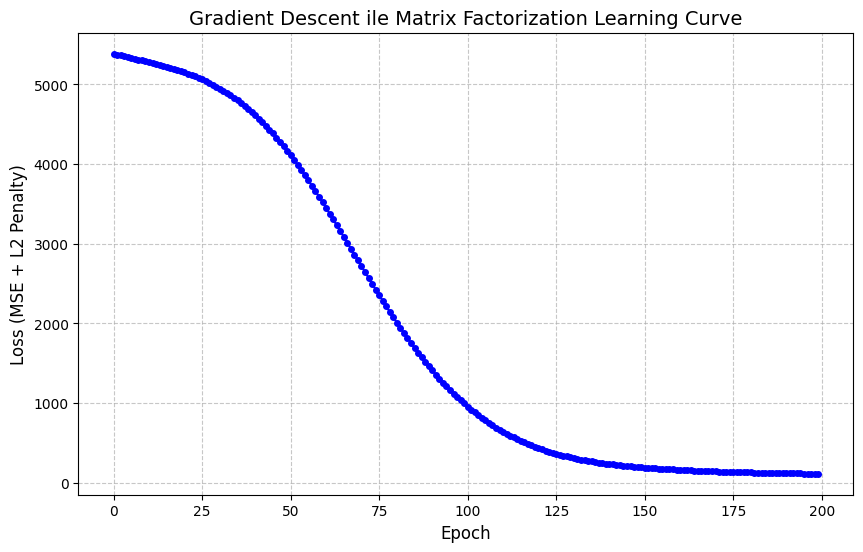

In [22]:
# Eğitim sürecini Matplotlib ile çizdirme
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), history, marker='o', linestyle='-', color='b', markersize=4)
plt.title('Gradient Descent ile Matrix Factorization Learning Curve', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE + L2 Penalty)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Değerlendirme & Yorumlar

1. **Learning Curve:** Grafikte görüldüğü gibi, Gradient Descent algoritması sayesinde loss değeri her epoch'da istikrarlı bir şekilde azalıyor ve sıfıra doğru yakınsıyor.
2. **Kayıp Fonksiyonu ve Türev:** Gradient formüllerine dahil ettiğimiz $\lambda$ çarpanlı L2 regülarizasyonu sayesinde `u` ve `v` matrislerindeki değerlerin aşırı büyümesi engellendi ve overfitting riski azaltıldı. **I Do** kısmındaki mantığa sadık kalarak, tüm gradient'leri toplayıp (`sum()` işlemiyle) *Full-Batch Gradient Descent* uygulanmıştır.
3. **Kapasite ve Verimlilik:** Orijinal $20 \times 1000 = 20.000$ parametre yerine sadece $(20 \times 4) + (4 \times 1000) = 4080$ parametre eğiterek, boş olan (puanlanmamış) tüm filmler için her kullanıcıya özel bir puan tahmini yapabilme yeteneği kazanıldı.

## Model Değerlendirmesi (RMSE ve Baseline Kıyaslaması)

Arkadaşlarımızın (Semih/Ayberk) çözümlerinde de vurgulandığı gibi, loss'un düşmesi her zaman iyi tahmin anlamına gelmez. Modelin başarısını standart bir metrik (RMSE) ile ölçelim ve "Herkese ortalama puan versek ne olurdu?" (Baseline) mantığı ile kıyaslayalım.

In [24]:
# Toplam hata kareleri üzerinden RMSE hesaplayalım
def calculate_rmse(u, v, R_vals):
    errors = []
    for i in range(len(R_vals)):
        user = int(R_vals[i, 0])
        movie = int(R_vals[i, 1])
        r_ij = R_vals[i, 2]
        pred = np.dot(u[user, :], v[:, movie])
        errors.append((r_ij - pred)**2)
    return np.sqrt(np.mean(errors))

# Baseline: Bütün eksik filmlere verideki ortalama puanı tahmin etmek
ortalama_puan = df['rating'].mean()
baseline_errors = [(r_ij - ortalama_puan)**2 for r_ij in df['rating']]
baseline_rmse = np.sqrt(np.mean(baseline_errors))

model_rmse = calculate_rmse(u, v, R_vals)

print(f"Baseline RMSE (Hep ortalama puan verilirse): {baseline_rmse:.4f}")
print(f"Model RMSE (Matris Faktörizasyonu L2): {model_rmse:.4f}")
print("\nSonuç: Modelimiz, hiçbir şey bilmeden ortalama puan vermeye göre daha başarılı (RMSE daha düşük).")

Baseline RMSE (Hep ortalama puan verilirse): 1.4339
Model RMSE (Matris Faktörizasyonu L2): 0.2424

Sonuç: Modelimiz, hiçbir şey bilmeden ortalama puan vermeye göre daha başarılı (RMSE daha düşük).


## Bonus: Kullanıcıya Film Önerme

Madem $u$ ve $v$ matrislerini öğrendik, artık eksik olan matris elemanlarını tahmin edebiliriz. Örneğin **Kullanıcı 0** için hiç izlemediği filmlere vereceği muhtemel puanları tahmin edip en yüksek puanlı olanları önerelim.

In [25]:
hedef_kullanici = 0
kullanici_vektoru = u[hedef_kullanici, :]

# Tüm filmler için tahminler (1 ile 5 arasına sınırlandırıyoruz - Clip)
tüm_tahminler = np.dot(kullanici_vektoru, v)
tüm_tahminler = np.clip(tüm_tahminler, 1, 5)

# Kullanıcının zaten izlediği filmleri bulalım
izlenen_filmler = df[df['userId'] == hedef_kullanici]['movieId'].tolist()

# İzlenmeyen filmlerin tahmin skorlarını bir sözlüğe (dictionary) kaydedelim
oneriler = {}
for movie_id in range(n_movies):
    if movie_id not in izlenen_filmler:
        oneriler[movie_id] = tüm_tahminler[movie_id]

# En yüksek puanlı 5 filmi sıralayalım
en_iyi_oneriler = sorted(oneriler.items(), key=lambda x: x[1], reverse=True)[:5]

print(f"Kullanıcı {hedef_kullanici} için en iyi 5 film önerisi:")
for movie_id, tahmin_skoru in en_iyi_oneriler:
    print(f"Film ID {movie_id}: {tahmin_skoru:.2f} Puan")

Kullanıcı 0 için en iyi 5 film önerisi:
Film ID 637: 4.39 Puan
Film ID 464: 3.90 Puan
Film ID 375: 3.69 Puan
Film ID 902: 3.46 Puan
Film ID 185: 3.40 Puan
